In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. Realice un notebook en el que se expliquen y programen los siguientes algoritmos de integración de ecuaciones diferenciales:

   (a) Integración con método de Euler.

   (b) Integración con método de Runge-Kutta de 2° orden.

   (c) Integración con método de Runge-Kutta de 4° orden.

Verifique el funcionamiento de sus integradores encontrando la solución de la siguiente ecuación diferencial para $x(t)$:

$$
\ddot{x} + 0.5\dot{x} + \sin{x}
=
e^{-t}\left(\sin(3t) + \cos(2t)\right)
\tag{1}
$$

Con condiciones iniciales

$$
\dot{x}(0) = 1
$$

y

$$
x(0) = 0.
$$

In [3]:
#EULER (RK1)

def RK1(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
    return sol

Para RK2 usé el modelo que viene en las notas, el siguiente:

$$
\vec{x}_{i+1}
=
\vec{x}_i
+
h \,
g\left(
\vec{x}_i
+
\frac{h}{2}
g\left(\vec{x}_i,t_i\right),
t_i+\frac{h}{2}
\right).
$$

In [18]:
# RK2

def RK2(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0), len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + (h*g(sol[:,i]+(0.5*h*g(sol[:,i],t[i])),t[i]+(h*0.5)))
    return sol

In [5]:
#RK4 (Tomé el que se hizo en clase)

def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i]+0.5*k1*h,t[i]+0.5*h)
        k3 = g(sol[:,i]+0.5*k2*h,t[i]+0.5*h)
        k4 = g(sol[:,i]+k3*h,t[i]+h)
        sol[:,i+1] = sol[:,i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return sol


Se tiene la ecuación diferencial

$$
\ddot{x} + 0.5\dot{x} + \sin{x}
=
e^{-t}\left(\sin(3t) + \cos(2t)\right).
$$

Para llevarla a la forma

$$
\frac{dx}{dt} = g(x,t)
$$

del método de Runge-Kutta, tomamos

$$
\frac{dx}{dt} = v.
$$

Sustituyendo esto en la ecuación diferencial a resolver, se tiene que

$$
\frac{dv}{dt} + 0.5v + \sin{x}
=
e^{-t}\left(\sin(3t) + \cos(2t)\right).
$$

Despejando, se obtiene que

$$
\frac{dv}{dt}
=
-0.5v - \sin{x}
+
e^{-t}\left(\sin(3t) + \cos(2t)\right).
$$
El sistema a resolver entonces queda como

$$
\frac{d}{dt}
\begin{pmatrix}
x \\
v
\end{pmatrix}
=
\begin{pmatrix}
v \\
-0.5v - \sin{x} + e^{-t}\left(\sin(3t) + \cos(2t)\right)
\end{pmatrix}.
$$

De esta manera, la función $g$ también termina teniendo dos entradas y dos salidas:

$$
g(x,t),
$$

donde

$$
x = \left(x[0],x[1]\right).
$$

Es decir,

$$
x[0] = x
$$

y

$$
x[1] = v.
$$


In [6]:
#DEFINICIÓN DE LA FUNCIÓN 

def g(x,t):
    dx = x[1]
    dv = - (0.5*x[1]) - (np.sin(x[0]))+ (np.exp(-t)*(np.sin(3*t) + np.cos(2*t)))
    return np.array([dx,dv])

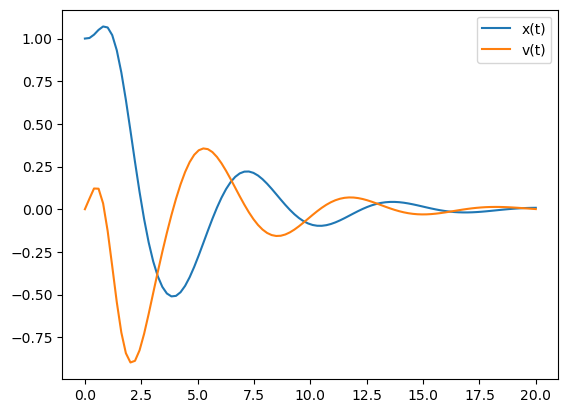

In [32]:
#Array de tiempo y condición inicial
t = np.linspace(0,20,100)
x0 = (1,0) 

#Solución con RK1
Sol_Rk1 = RK1(g,x0,t)
plt.plot(t,Sol_Rk1[0,:], label = 'x(t)')
plt.plot(t,Sol_Rk1[1,:], label = 'v(t)')
plt.legend()
plt.show()

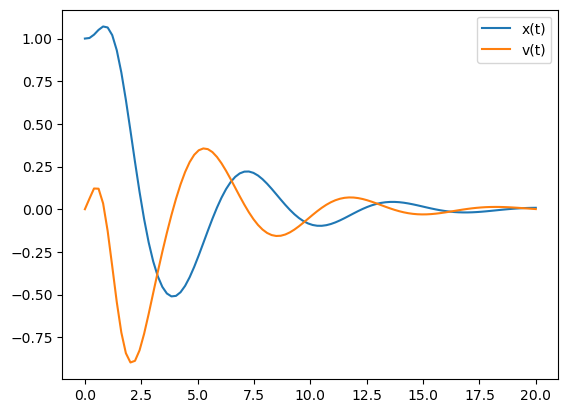

In [28]:
#Solución con RK2

Sol_Rk2= RK2(g,x0,t)
plt.plot(t,Sol_Rk2[0,:], label = 'x(t)')
plt.plot(t,Sol_Rk2[1,:], label = 'v(t)')
plt.legend()
plt.show()

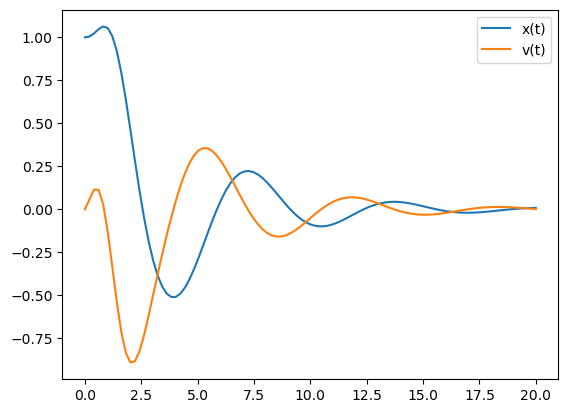

In [29]:
#Solución con RK4

Sol_Rk4= RK4(g,x0,t)
plt.plot(t,Sol_Rk4[0,:], label = 'x(t)')
plt.plot(t,Sol_Rk4[1,:], label = 'v(t)')
plt.legend()
plt.show()

2. Utilizando los integradores anteriores, encuentre un paso que le asegure que la solución tenga por lo menos 4 cifras significativas en el resultado de integración. La ecuación es la siguiente:

$$
\dddot{y} + \ddot{y}^{2} - 3\dot{y}^{3} + \cos^{2}{y}
=
e^{-t}\sin(3t)
\tag{2}
$$

Con condiciones iniciales

$$
\ddot{y}(1) = 1,
\qquad
\dot{y}(1) = 2,
\qquad
y(1) = 1.
$$

En particular, qué sucede en el intervalo

$$
t \in [1,1.65],
$$

describa lo que sucede cuando

$$
t \to 2.
$$

In [33]:
# Para RK1

Tomando

$$
\frac{dv}{dt} = a,
\qquad
\frac{dy}{dt} = v,
$$

y sustituyendo en la ecuación diferencial a resolver, se tiene que

$$
\frac{da}{dt}
=
-a^2 +3v^3 - \cos^2{y} + e^{-t}\sin(3t).
$$

Con esto podemos construir la función $g$.

In [66]:
#DEFIINICÓN DE LA FUNCIÓN 

def g2(x,t):
    dx = x[1]
    dv = x[2]
    da = -x[2]**2 + 3*x[1]**3 - np.cos(x[0])**2 + (np.exp(-t)*np.sin(3*t))
    return np.array([dx,dv,da])

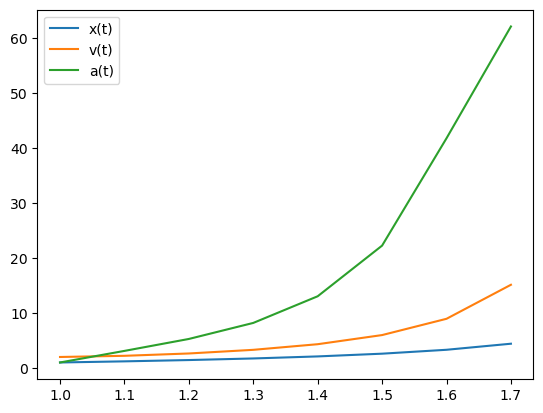

In [74]:
delta = 0.1
t2 = np.arange(1, 1.65 + delta, delta)
x02 = (1,2,1) 

#Solución con RK1
Sol_Rk1_2 = RK1(g2,x02,t2)
plt.plot(t2,Sol_Rk1_2[0,:], label = 'x(t)')
plt.plot(t2,Sol_Rk1_2[1,:], label = 'v(t)')
plt.plot(t2,Sol_Rk1_2[2,:], label = 'a(t)')
plt.legend()
plt.show()

In [84]:
delta = 0.1
t = np.arange(1,1.65+delta,delta)
x_v = RK1(g2,x02,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
contador = 10
deltas = np.zeros(contador)
for i in range(contador):
    delta = 0.5*delta
    t = np.arange(1,1.65+delta,delta)
    x_v = RK1(g,x0,t)
    deltas[i] = delta
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 1.7000000000000006 4.414836355235114
0.05 1.6500000000000006 0.7820024314881553
0.025 1.6499999999999977 0.7821412111138485
0.0125 1.6499999999999977 0.7821779418784881
0.00625 1.6500000000000092 0.7821873743532167
0.003125 1.6500000000000092 0.7821897634034821
0.0015625 1.649999999999963 0.7821903645143884
0.00078125 1.649999999999963 0.7821905152720134
0.000390625 1.6500000000001478 0.7821905530212179
0.0001953125 1.6500000000001478 0.7821905624660341
9.765625e-05 1.6499999999994088 0.7821905648286505


Conclusión: Con RK1, se mantuvieron estables las primeras cuatro cifras a partir del paso delta=0.025

In [ ]:
#Para RK2 

In [85]:
delta = 0.1
t = np.arange(1,1.65+delta,delta)
x_v = RK2(g2,x02,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
contador = 10
deltas = np.zeros(contador)
for i in range(contador):
    delta = 0.5*delta
    t = np.arange(1,1.65+delta,delta)
    x_v = RK2(g,x0,t)
    deltas[i] = delta
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 1.7000000000000006 4.414836355235114
0.05 1.6500000000000006 0.7820024314881553
0.025 1.6499999999999977 0.7821412111138485
0.0125 1.6499999999999977 0.7821779418784881
0.00625 1.6500000000000092 0.7821873743532167
0.003125 1.6500000000000092 0.7821897634034821
0.0015625 1.649999999999963 0.7821903645143884
0.00078125 1.649999999999963 0.7821905152720134
0.000390625 1.6500000000001478 0.7821905530212179
0.0001953125 1.6500000000001478 0.7821905624660341
9.765625e-05 1.6499999999994088 0.7821905648286505


In [86]:
#Para RK4

In [87]:
delta = 0.1
t = np.arange(1,1.65+delta,delta)
x_v = RK4(g2,x02,t)
pto_ref = x_v[0,-1]
print(delta,t[-1],pto_ref)
contador = 10
deltas = np.zeros(contador)
for i in range(contador):
    delta = 0.5*delta
    t = np.arange(1,1.65+delta,delta)
    x_v = RK4(g,x0,t)
    deltas[i] = delta
    pto_ref = x_v[0,-1]
    print(delta,t[-1],pto_ref)

0.1 1.7000000000000006 4.036113094016291
0.05 1.6500000000000006 0.7821905712304134
0.025 1.6499999999999977 0.782190565967402
0.0125 1.6499999999999977 0.7821905656377879
0.00625 1.6500000000000092 0.7821905656171921
0.003125 1.6500000000000092 0.7821905656159066
0.0015625 1.649999999999963 0.7821905656158552
0.00078125 1.649999999999963 0.7821905656158492
0.000390625 1.6500000000001478 0.7821905656157316
0.0001953125 1.6500000000001478 0.7821905656157309
9.765625e-05 1.6499999999994088 0.7821905656162081


Conclusión: Para el caso de RK2, dejaron de cambiar también a partir de delta=0.025, por otro lado, para RK4, deja de cambiar a partir de delta=0.05